# RevGuard — Model Evaluation

RevGuard's Isolation Forest is unsupervised: it never sees fraud labels. But the synthetic
data generator embeds ground truth — ~3% of users follow one of three fraud personas
(*serial returner*, *high-value abuser*, *wardrober*), recorded in
`data/processed/fraud_labels.csv` and **used only here, never in training**.

That lets us answer the question an anomaly detector usually can't:
**are the flags actually right?**

1. Ground-truth detection metrics (ROC-AUC, precision@k, band precision/recall)
2. Contamination sensitivity — the alert-volume vs. precision trade-off
3. What drives the flags (SHAP)
4. Audit of the top-20 flagged users
5. Summary and honest limitations

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from backend.ml.pipeline import FraudPipeline

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
BLUE, ORANGE, GRAY, RED = '#4C78A8', '#E8871E', '#9AA0A6', '#C4443C'
FEATURES = FraudPipeline.FEATURE_COLS

df = pd.read_csv(config.DATA_PATH, parse_dates=['purchase_date', 'return_date'])
print(f"{len(df):,} transactions | {df.user_id.nunique():,} users | "
      f"{df.purchase_date.min().date()} to {df.purchase_date.max().date()}")
df.head()

10,981 transactions | 1,500 users | 2023-01-09 to 2024-12-30


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,user_id,order_id,item_id,purchase_date,return_date,return_reason,refund_amount,payment_method,receipt_id
0,USER00000000,ORD00000000,PROD00000836,2024-02-29,NaT,Not Returned,326.99,PayPal,ORD00000000-PROD00000836
1,USER00000000,ORD00000001,PROD00001539,2024-04-11,2024-04-27,Defective,105.97,Credit Card,ORD00000001-PROD00001539
2,USER00000000,ORD00000002,PROD00002669,2024-06-11,NaT,Not Returned,99.73,PayPal,ORD00000002-PROD00002669
3,USER00000000,ORD00000003,PROD00001711,2024-08-08,NaT,Not Returned,1478.39,Credit Card,ORD00000003-PROD00001711
4,USER00000000,ORD00000004,PROD00000840,2024-09-25,NaT,Not Returned,48.65,PayPal,ORD00000004-PROD00000840


In [2]:
labels = pd.read_csv('data/processed/fraud_labels.csv')
uf = pd.read_pickle(config.USER_FEATURES_PATH)     # production model's scores
m = uf.merge(labels, on='user_id', how='inner')
n_fraud = int(m.is_fraud.sum())
print(f"scored users: {len(m):,} | labeled fraudsters among them: {n_fraud} "
      f"(base rate {m.is_fraud.mean():.1%})")
print(m[m.is_fraud == 1].persona.value_counts().to_string())

scored users: 962 | labeled fraudsters among them: 45 (base rate 4.7%)
persona
wardrober            17
high_value_abuser    16
serial_returner      12


## 1. Ground-truth detection metrics

The model outputs a *ranking* (risk score 0–100). Two views of quality:

- **ROC-AUC / average precision** — how well the score separates fraudsters from normal users overall.
- **Precision@k / recall@k** — what an investigator experiences: if you work the top *k*
  highest-risk users, how many are real, and what share of all fraud do you catch?

In [3]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

auc = roc_auc_score(m.is_fraud, m['Risk Score'])
ap = average_precision_score(m.is_fraud, m['Risk Score'])

high = m[m['Risk Band'] == 'High']
band_precision = high.is_fraud.mean()
band_recall = high.is_fraud.sum() / n_fraud

print(f"ROC-AUC:            {auc:.3f}")
print(f"Average precision:  {ap:.3f}  (base rate {m.is_fraud.mean():.3f})")
print(f"High band ({len(high)} users): precision {band_precision:.2f}, recall {band_recall:.2f}")
print()
print("Recall into High band, by persona:")
print(m[m.is_fraud == 1].groupby('persona')
       .apply(lambda g: (g['Risk Band'] == 'High').mean(), include_groups=False)
       .round(2).to_string())

ROC-AUC:            0.981
Average precision:  0.618  (base rate 0.047)
High band (42 users): precision 0.69, recall 0.64

Recall into High band, by persona:
persona
high_value_abuser    0.56
serial_returner      0.50
wardrober            0.82


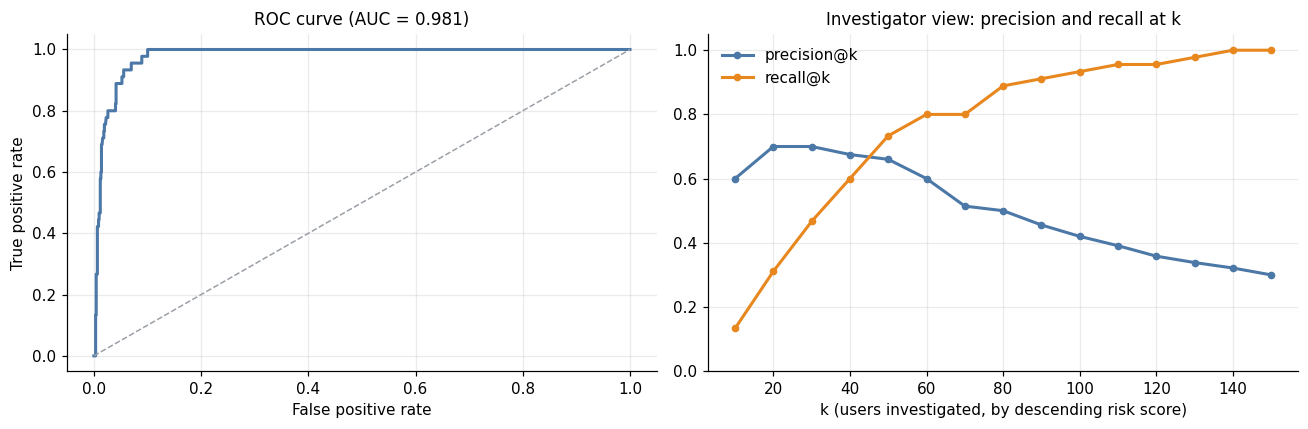

In [4]:
sorted_m = m.sort_values('Risk Score', ascending=False).reset_index(drop=True)
ks = list(range(10, 151, 10))
prec_k = [sorted_m.is_fraud[:k].mean() for k in ks]
rec_k = [sorted_m.is_fraud[:k].sum() / n_fraud for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fpr, tpr, _ = roc_curve(m.is_fraud, m['Risk Score'])
axes[0].plot(fpr, tpr, color=BLUE, lw=2)
axes[0].plot([0, 1], [0, 1], color=GRAY, lw=1, ls='--')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title(f'ROC curve (AUC = {auc:.3f})')

axes[1].plot(ks, prec_k, color=BLUE, lw=2, marker='o', ms=4, label='precision@k')
axes[1].plot(ks, rec_k, color=ORANGE, lw=2, marker='o', ms=4, label='recall@k')
axes[1].set_xlabel('k (users investigated, by descending risk score)')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Investigator view: precision and recall at k')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

Reading the right-hand panel as an operations question: a small investigation budget
(the first few dozen cases) is dominated by true fraudsters, and recall climbs steeply
because the fraud population is small. Past the point where recall flattens, additional
investigations mostly surface unusual-but-legitimate customers — that inflection is where
the High-band threshold should sit.

## 2. Contamination sensitivity

`contamination` does **not** change the ranking (the isolation scores are identical);
it only moves the cutoff that converts scores into flags. So the real question is
operational: how do precision and recall of the *flagged set* trade off as the alert
volume grows?

,contamination,n_flagged,precision,recall
0,0.01,10,0.600,0.133
1,0.02,20,0.700,0.311
2,0.03,29,0.690,0.444
3,0.05,49,0.653,0.711
4,0.08,77,0.506,0.867
5,0.10,97,0.433,0.933
6,0.12,116,0.371,0.956
7,0.15,144,0.312,1.000


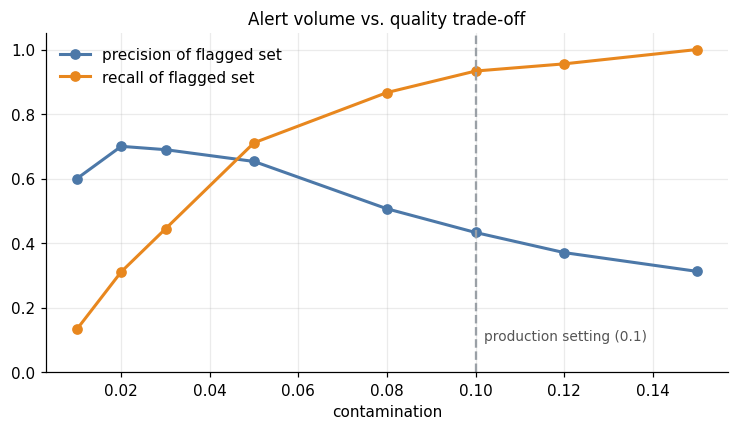

In [5]:
from sklearn.ensemble import IsolationForest

X = m[FEATURES]
rows = []
for c in [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15]:
    iso = IsolationForest(contamination=c, random_state=42, n_estimators=100).fit(X)
    flagged = iso.predict(X) == -1
    rows.append({'contamination': c, 'n_flagged': int(flagged.sum()),
                 'precision': m.is_fraud[flagged].mean(),
                 'recall': m.is_fraud[flagged].sum() / n_fraud})
sweep = pd.DataFrame(rows)
display(sweep.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep.contamination, sweep.precision, color=BLUE, lw=2, marker='o', label='precision of flagged set')
ax.plot(sweep.contamination, sweep.recall, color=ORANGE, lw=2, marker='o', label='recall of flagged set')
ax.axvline(config.CONTAMINATION_RATE, color=GRAY, lw=1.5, ls='--')
ax.text(config.CONTAMINATION_RATE + 0.002, 0.1, f'production setting ({config.CONTAMINATION_RATE})',
        fontsize=9, color='#555')
ax.set_xlabel('contamination')
ax.set_ylim(0, 1.05)
ax.set_title('Alert volume vs. quality trade-off')
ax.legend(frameon=False)
plt.show()

The labeled fraud base rate among scored users is ≈5%, so precision decays roughly in
proportion once contamination exceeds it — flag budget beyond the true fraud population is
spent on false positives. Recall, meanwhile, is already near its ceiling at contamination
≈ 0.05. In production the risk *bands* (not the raw contamination flag) gate investigations,
which keeps this choice low-stakes, but the sweep documents why a value near the expected
fraud rate is the right neighborhood.

## 3. What drives the flags (SHAP)

`shap.TreeExplainer` attributes each user's isolation score to the six features. Sign
convention for Isolation Forest: **negative SHAP pushes the decision score down, i.e.
toward "more anomalous" — negative contributions increase risk.**

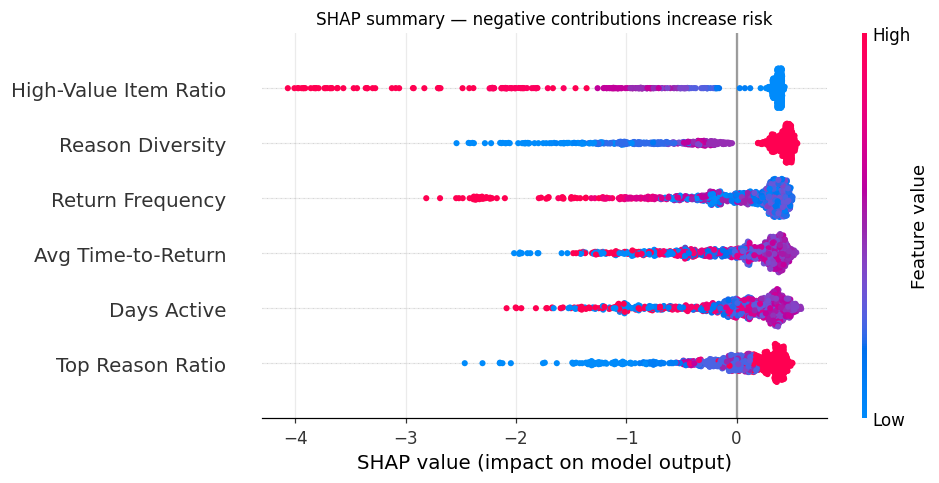

In [6]:
import pickle, shap

with open(config.MODEL_PATH, 'rb') as f:
    model = pickle.load(f)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False, plot_size=(9, 4.5))
plt.title('SHAP summary — negative contributions increase risk', fontsize=11)
plt.tight_layout()
plt.show()

High Return Frequency and high High-Value Item Ratio produce the strongest
risk-increasing (leftward) contributions — matching the serial-returner and high-value-abuser
personas — while fast returns and low reason diversity add the wardrobing signature. This is
the model-level counterpart of the per-user SHAP breakdown shown in the dashboard's
"Why was this user flagged?" panel.

## 4. Audit of the top-20 flagged users

The persona column is revealed only after ranking — the model saw none of it.

In [7]:
cols = ['user_id', 'Risk Score', 'Risk Band'] + FEATURES + ['persona']
top20 = sorted_m.head(20)
display(top20[cols].round(1))
tp = int(top20.is_fraud.sum())
print(f"true fraudsters in top 20: {tp}/20")

,user_id,Risk Score,Risk Band,Return Frequency,High-Value Item Ratio,Avg Time-to-Return,Reason Diversity,Days Active,Top Reason Ratio,persona
0,USER00000867,100.0,High,100.0,100.0,28.0,1.0,0,1.0,normal
1,USER00000701,95.5,High,100.0,100.0,10.0,1.0,0,1.0,normal
2,USER00001356,94.4,High,100.0,100.0,23.0,1.0,0,1.0,normal
3,USER00000382,88.8,High,71.4,40.0,3.2,0.2,573,0.9,wardrober
4,USER00001002,88.2,High,78.9,60.0,13.3,0.2,619,0.4,high_value_abuser
5,USER00000605,87.7,High,84.6,36.4,3.2,0.2,622,0.6,wardrober
6,USER00001398,87.6,High,71.4,53.3,3.0,0.2,236,0.9,wardrober
7,USER00000398,87.6,High,90.0,33.3,1.7,0.2,163,0.9,wardrober
8,USER00000013,86.0,High,88.9,15.6,13.2,0.1,690,0.5,serial_returner
9,USER00001385,85.9,High,50.0,100.0,3.0,1.0,22,1.0,normal


true fraudsters in top 20: 14/20


## 5. Summary

In [8]:
print("Headline metrics (production model vs. held-out persona labels)")
print("-" * 62)
print(f"ROC-AUC                      {auc:.3f}")
print(f"Average precision            {ap:.3f}   (base rate {m.is_fraud.mean():.3f})")
print(f"Precision@50 / Recall@50     {sorted_m.is_fraud[:50].mean():.2f} / {sorted_m.is_fraud[:50].sum()/n_fraud:.2f}")
print(f"High band ({len(high)} users)         precision {band_precision:.2f} / recall {band_recall:.2f}")
print(f"Top-20 audit                 {int(sorted_m.is_fraud[:20].sum())}/20 true fraudsters")

Headline metrics (production model vs. held-out persona labels)
--------------------------------------------------------------
ROC-AUC                      0.981
Average precision            0.618   (base rate 0.047)
Precision@50 / Recall@50     0.66 / 0.73
High band (42 users)         precision 0.69 / recall 0.64
Top-20 audit                 14/20 true fraudsters


### Limitations — read before quoting the numbers

- **The personas are synthetic and engineered to be behaviorally distinct.** Real fraud is
  adversarial and subtler; these metrics are an upper bound, not a production claim. The right
  reading is "the pipeline correctly isolates the behaviors it was designed to catch."
- **No temporal validation.** Features are computed over each user's full history; a deployed
  system should score on a rolling window and be back-tested against later outcomes.
- **Min-max score normalization is cohort-relative**, so a user's 0–100 score can shift when
  the population changes, even if their behavior doesn't.
- **Next steps:** collect analyst dispositions from the dashboard's investigator actions as
  weak labels, then compare the unsupervised ranking against a supervised baseline.